In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
df=pd.read_csv('/content/car_price_prediction.csv')
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [ ]:
df.columns

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='object')

In [ ]:
X = df[['Year', 'Engine Size', 'Mileage', 'Condition']]
y = df['Price']

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
df[df.isin(['New']).any(axis=1)]

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
7,8,Tesla,2017,5.3,Hybrid,Automatic,83030,New,17381.19,Model Y
12,13,Ford,2006,4.7,Petrol,Automatic,114360,New,74766.45,Fiesta
...,...,...,...,...,...,...,...,...,...,...
2482,2483,Honda,2006,2.3,Electric,Automatic,282615,New,78674.31,Civic
2483,2484,Mercedes,2014,2.9,Diesel,Manual,91820,New,81838.19,GLA
2491,2492,Toyota,2019,4.2,Hybrid,Manual,75955,New,28041.25,Prius
2492,2493,Tesla,2002,2.7,Petrol,Manual,147748,New,66352.03,Model X


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Brand'] = le.fit_transform(df['Brand'])
df['Fuel Type'] = le.fit_transform(df['Fuel Type'])
df['Transmission'] = le.fit_transform(df['Transmission'])
df['Condition'] = le.fit_transform(df['Condition'])
df['Model'] = le.fit_transform(df['Model'])

In [ ]:
X = df[['Year', 'Engine Size', 'Mileage', 'Condition', 'Brand', 'Fuel Type', 'Transmission']]
y = df['Price']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
df[df.isin(['New']).any(axis=1)]

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model



y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 23772.91221832406
MSE: 760832500.140906
R2 Score: -0.004328629704661635


In [ ]:
r̥r̥import pandas as pd

new_car = pd.DataFrame({
    'Year': [2020],
    'Engine Size': [1.5],
    'Mileage': [15000],
    'Condition': [8],
    'Brand': [2],
    'Fuel Type': [1],
    'Transmission': [1]
})

predicted_price = model.predict(new_car)
print("Predicted Car Price:", predicted_price[0])

Predicted Car Price: 52238.45319492917


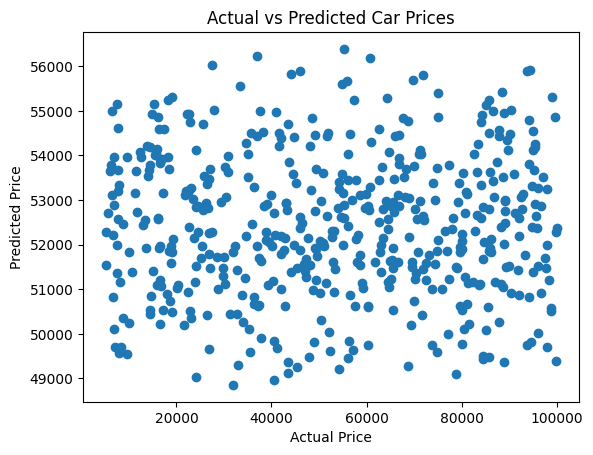

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

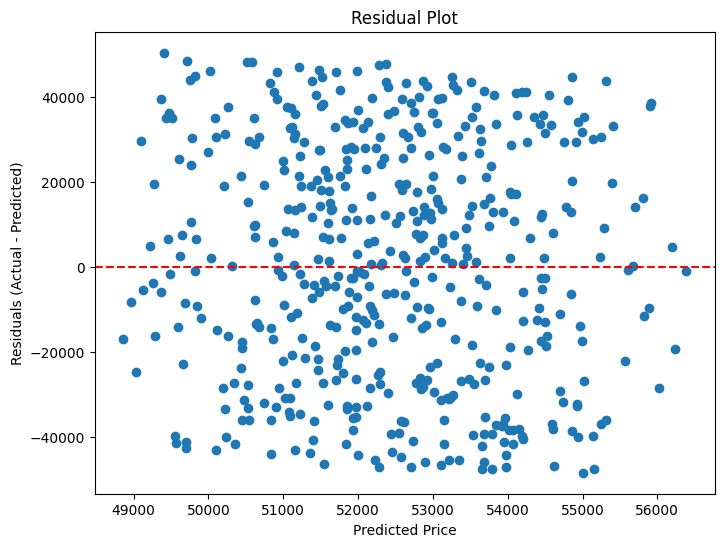

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

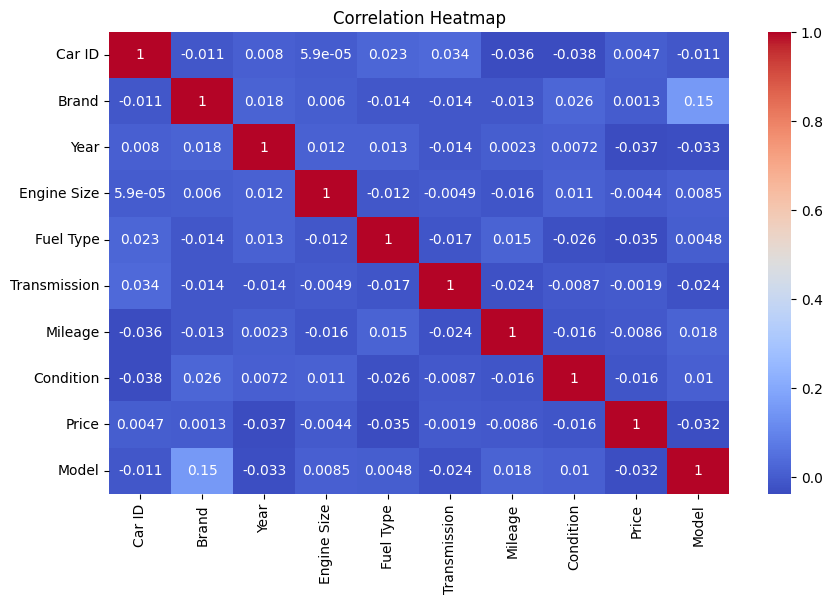

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

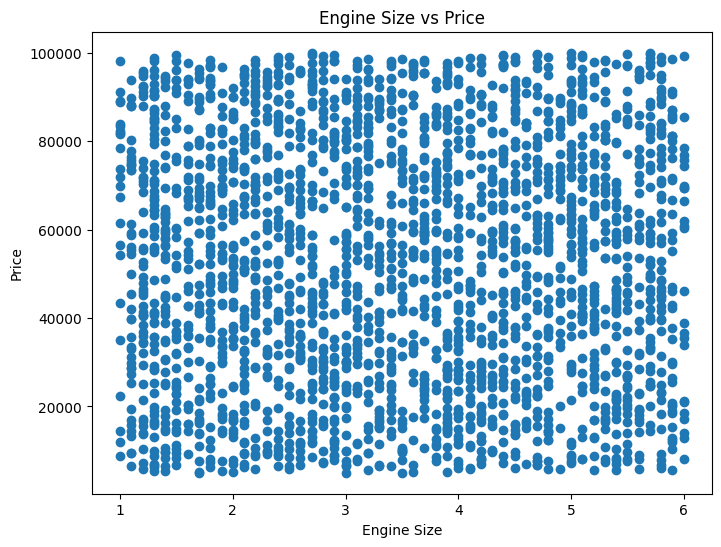

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['Engine Size'], df['Price'])
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.title("Engine Size vs Price")
plt.show()